In [1]:
import numpy as np
from scipy.integrate import simpson
from scipy.signal import windows
from scipy.signal import detrend
import matplotlib.pyplot as plt

In [2]:
res = np.loadtxt("11111.txt", delimiter=",", comments="#")

# 光谱波数
nu = res[:, 0]
# 光谱强度
Snu = res[:, 1] / 100

In [3]:
opd = (-0.2, 0.2)  # 光程差范围
sample_num = 16384  # 采样点数

In [4]:
x = np.linspace(opd[0], opd[1], sample_num)
print(x.shape, x)

nu_x_matrix = np.outer(nu, x)

print(nu_x_matrix.shape)

cos_matrix = np.cos(2 * np.pi * nu_x_matrix)

print(cos_matrix.shape)

d_nu = 3.078696
interferogram = np.dot(Snu, cos_matrix) * d_nu
print(interferogram.shape)
print(interferogram)

(16384,) [-0.2        -0.19997558 -0.19995117 ...  0.19995117  0.19997558
  0.2       ]
(2598, 16384)
(2598, 16384)
(16384,)
[ 2.30720663  1.56912442 -1.39061989 ... -1.39061989  1.56912442
  2.30720663]


In [7]:
interferogram_detrend = detrend(interferogram, type="constant")

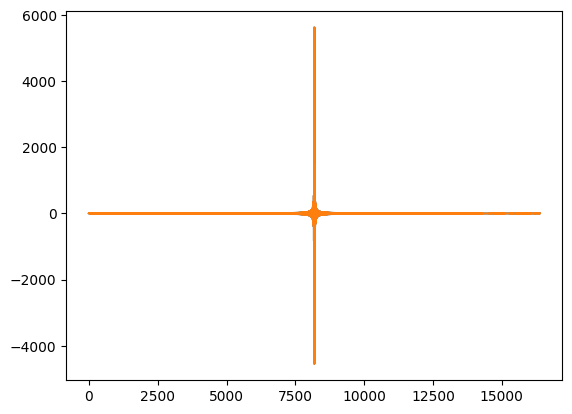

In [9]:
plt.plot(interferogram)
plt.plot(interferogram_detrend)
plt.show()

In [10]:
16384/2

8192.0